![卷积神经网络图像分类器](images/卷积神经网络图像分类器.png)

# 知识要点
- 数据加载与归一
- 定义神经网络
- 定义损失函数
- 训练、测试神经网络
- 神经网络存储与读取

<br>

## 数据加载与归一
- 数据加载
    - 把训练数据导入到神经网络中并对神经网络进行训练
    -  图像分类器训练数据一般较大，无法一次性加载所有数据
        - 例如
            - CIFAR10数据集含有10个类6万张图片
            - ImageNet数据集包含1000个类超过100万张图片
        - 需要用mini-batch形式进行加载并训练
            - 每个mini-batch只加载所有训练数据集中的一部分数据
            - 任意两个mini-batch之间的数据不重叠
            - 当所有训练数据集中的数据都被加载并训练完一次被称为一个epoch
- 数据归一
    - 图像数据像素值一般在[0-255]
    - 在训练神经网络时，我们经常把输入数据值变成[0-1]或[-1 - 1]之间。可以加速收敛、提高模型稳定性、避免梯度消失和梯度爆炸问题，并提高模型的泛化能力
- PyTorch库
    - 数据加载
        - torchvision.dataset
            - 知名数据集可用torchvision.dataset.数据集名称加载
                - 例如：torchvision.datasets.CIFAR10 加载CIFAR10数据集
            - 私人数据集可用torchvision.dataset.ImageFolder 和 torch.utils.data.DataLoader加载
    - 数据归一
        - torchvision.transforms

## 常用公共数据集加载
### 数据集 CIFAR10
- CIFAR10是学习阶段常用的小型图像数据集
- CIFAR10有10类
    - 每类6000张图片
- 图像大小：32 * 32 * 3
    - 每张图有R、G、B三个通道
    - 每个通道有32*32个像素

![数据集CIFAR10](images/数据集CIFAR10.png)
           

In [7]:
import torch
import torchvision
import torchvision.transforms as transforms

In [8]:
# 定义数据转换
transforms = transforms.Compose(
    [
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
    ]
)

# 加载训练数据集
train_set = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transforms)
train_loader = torch.utils.data.DataLoader(train_set, batch_size=4, shuffle=True, num_workers=2) # batch_size 影响

# 加载测试数据集
test_set = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transforms)
test_loader = torch.utils.data.DataLoader(test_set, batch_size=4, shuffle=False, num_workers=2)

Files already downloaded and verified
Files already downloaded and verified


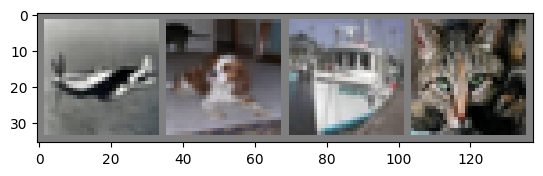

In [3]:
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline

# 定义显示图像的函数
def imshow(img):
    # 输入数据：torch.tensor [c, h, w]
    img = img / 2 + 0.5  # 反归一化
    np_img = img.numpy()
    np_img = np.transpose(np_img, (1,2,0)) # [h,w,c]
    plt.imshow(np_img)
    plt.show()

# 获取一个批次的数据
dataiter = iter(train_loader) # 随机加载一个mini batch。随机是为了避免学习到顺序行的知识，提高模型的泛化能力
images, labels = next(dataiter)  # 使用 next() 函数

# 显示图像
imshow(torchvision.utils.make_grid(images))

## 加载私人数据集

In [ ]:
import torch
import torchvision
import torchvision.transforms as transforms

In [ ]:
# 定义数据转换
transforms = transforms.Compose(
    [
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
    ]
)

# 加载训练数据集
private_set = torchvision.datasets.ImageFolder(root=image_path, transform=transforms)
pri_dataloader = torch.utils.data.DataLoader(private_set, batch_size=4, shuffle=False, num_workers=2)

- PyTorch会将image_path下面的数据在训练或测试时自动加载
- 在训练模型的时候，PyTorch会根据image_path下子文件夹的名称自动给所加载的数据添加标签
- 在加载私人数据集的时候，数据集所在文件夹应保持一下结构：
```plaintext
/toy_dataset
    /class_1
    /class_2
    ... 

## 定义神经网络

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F

In [2]:
class Net(nn.Module):
    def __init__(self): # 定义神经网络结构，输入数据 1*32*32
        super(Net, self).__init__()
        # 第一层（卷积层）
        self.conv1 = nn.Conv2d(3, 6, 3) # 输入频道3， 输出频道6， 卷积3*3
        # 第二层（卷积层）
        self.conv2 = nn.Conv2d(6, 16, 3) # 输入频道6， 输出频道16， 卷积3*3
        # 第三层（全连接层）
        self.fc1 = nn.Linear(16*28*28, 512) # 输入维度16*28*28=12544，输出维度512.这里的28，是因为经过每一层都会减2，32-2-2=28
        # 第四层（全连接层）
        self.fc2 = nn.Linear(512, 64) # 输入维度512， 输出维度64
        # 第五层（全连接层）
        self.fc3 = nn.Linear(64, 10) # 输入维度64， 输出维度10
        
    def forward(self, x): # 定义数据流向
        x = self.conv1(x)
        x = F.relu(x) # 激活函数
        
        x = self.conv2(x)
        x = F.relu(x)
        
        x = x.view(-1, 16*28*28) # 将卷积层的输出张量重新调整形状，以便输入到全连接层，这个操作通过被成为“展平”。-1表示让torch自动计算该维度的大小，以确保元素总数不变，16 * 28 * 28：这是卷积层输出的特征图的总元素数量。16 是通道数，28 是高度，28 是宽度
        x = self.fc1(x)
        x = F.relu(x)
        
        x = self.fc2(x)
        x = F.relu(x)
        
        x = self.fc3(x) # 在神经网络的最后一层通常不需要使用激活函数，最后一层的输出通常会直接传递给损失函数进行计算
        
        return x

In [3]:
net = Net()
print(net)

Net(
  (conv1): Conv2d(3, 6, kernel_size=(3, 3), stride=(1, 1))
  (conv2): Conv2d(6, 16, kernel_size=(3, 3), stride=(1, 1))
  (fc1): Linear(in_features=12544, out_features=512, bias=True)
  (fc2): Linear(in_features=512, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=10, bias=True)
)


## 定义权值更新规则与损失函数

In [4]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(net.parameters(), lr=0.001, momentum=0.9) # 学习率

## 训练神经网络

In [ ]:
for epoch in range(2): # epoch次数
    for i, data in enumerate(train_loader):
        images, labels = data
        outputs = net(images)
        loss = criterion(outputs, labels) # 计算损失
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        if (i%1000 == 0):
            print('Epoch: %d, Steop: %d, Loss: %.3f' %(epoch, i, loss.item()))

## 影响loss
- 梯度下降优化器中的学习率
    - optim.SGD(net.parameters(), lr=0.0001, momentum=0.9)，其中的lr，越小学的越好，但是相应的训练的时长越长
- 加载数据的batch_size，越大越大可能导致内存不足，训练速度变慢，但梯度估计更稳定，越小可能导致梯度估计不稳定，训练速度变快，但可能需要更多的迭代次数才能收敛
    - torch.utils.data.DataLoader(train_set, batch_size=4, shuffle=True, num_workers=2)
- 训练轮数epoch
    - 过少：可能导致模型欠拟合，无法充分学习数据中的模式
    - 过多：可能导致模型过拟合，学习到噪声和无关的模式
- 神经网络的层数

## loss 优化版

In [9]:
import torch.optim as optim
from tqdm import tqdm

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(net.parameters(), lr=0.0001, momentum=0.9)

In [10]:
# 检测 GPU 是否可用
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# 将模型移动到 GPU
net.to(device)

Using device: cuda


Net(
  (conv1): Conv2d(3, 6, kernel_size=(3, 3), stride=(1, 1))
  (conv2): Conv2d(6, 16, kernel_size=(3, 3), stride=(1, 1))
  (fc1): Linear(in_features=12544, out_features=512, bias=True)
  (fc2): Linear(in_features=512, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=10, bias=True)
)

In [ ]:
train_loss_hist = [] # 用于记录训练损失的历史值
test_loss_hist = [] # 用于记录测试损失的历史值

for epoch in tqdm(range(20)): # 循环 20 个 epoch，并使用 tqdm 显示进度条
    # 训练
    net.train() # 将模型设置为训练模式
    running_loss = 0.0 # 初始化运行损失
    for i, data in enumerate(train_loader): # 遍历训练数据加载器
        images, labels = data # 获取训练图像和标签
        
        # 将数据移动到 GPU
        images = images.to(device)
        labels = labels.to(device)
        
        outputs = net(images) # 前向传播，获取模型输出
        loss = criterion(outputs, labels) # 计算损失
        
        optimizer.zero_grad() # 清零梯度。在每次反向传播之前，清零模型参数的梯度。这是为了避免梯度累积，确保每次反向传播都是基于当前批次的数据
        loss.backward() # 反向传播，计算梯度
        optimizer.step() # 更新模型参数，使损失指减小
        # 损失函数（Loss Function）用于衡量模型预测值与真实值之间的差异。损失值越小，表示模型的预测越接近真实值。损失函数是优化算法的目标函数，优化算法的目标是最小化损失值。
        # 梯度是一个向量，表示函数在某一点处的变化率。对于损失函数，梯度表示损失函数在模型参数空间中的变化率。作用：梯度指向损失函数增加最快的方向，负梯度指向损失函数减少最快的方向。优化算法（如梯度下降）利用梯度来更新模型参数，使损失值减小
        # 梯度是损失函数的导数：梯度是损失函数在模型参数空间中的导数，表示损失函数在每个参数上的变化率。梯度下降：优化算法通过计算损失函数的梯度，沿着负梯度方向更新模型参数，使损失值逐渐减小。
        
        running_loss += loss.item() # 累加运行损失
        if i%250 == 0: # 每250 mini batch 测试一次
            print('Epoch: %d, Steop: %d, Loss: %.3f' %(epoch, i, loss.item()))
            
            
            correct = 0.0
            total = 0.0
            
            net.eval() # 将模型设置为评估模式
            with torch.no_grad(): # 禁用梯度计算，节省内存
                for test_data in test_loader: # 遍历测试数据加载器
                    test_images, test_labels = test_data # 获取测试图像和标签
                    
                    # 将数据移动到 GPU
                    test_images = test_images.to(device)
                    test_labels = test_labels.to(device)
                    
                    test_outputs = net(test_images) # 前向传播，获取模型输出
                    test_loss = criterion(test_outputs, test_labels) # 计算测试损失
                    
            train_loss_hist.append(running_loss/250) # 记录训练损失
            test_loss_hist.append(test_loss.item()) # 记录测试损失
            running_loss=0.0 # 重置运行损失

  0%|          | 0/20 [00:00<?, ?it/s]

Epoch: 0, Steop: 0, Loss: 0.894
Epoch: 0, Steop: 250, Loss: 1.253
Epoch: 0, Steop: 500, Loss: 0.679
Epoch: 0, Steop: 750, Loss: 1.536
Epoch: 0, Steop: 1000, Loss: 0.435
Epoch: 0, Steop: 1250, Loss: 0.704
Epoch: 0, Steop: 1500, Loss: 0.804
Epoch: 0, Steop: 1750, Loss: 1.262
Epoch: 0, Steop: 2000, Loss: 1.749
Epoch: 0, Steop: 2250, Loss: 0.619
Epoch: 0, Steop: 2500, Loss: 0.508
Epoch: 0, Steop: 2750, Loss: 0.483
Epoch: 0, Steop: 3000, Loss: 0.581
Epoch: 0, Steop: 3250, Loss: 1.199
Epoch: 0, Steop: 3500, Loss: 1.405
Epoch: 0, Steop: 3750, Loss: 0.837
Epoch: 0, Steop: 4000, Loss: 0.863
Epoch: 0, Steop: 4250, Loss: 1.062
Epoch: 0, Steop: 4500, Loss: 1.140
Epoch: 0, Steop: 4750, Loss: 1.461
Epoch: 0, Steop: 5000, Loss: 1.243
Epoch: 0, Steop: 5250, Loss: 0.475
Epoch: 0, Steop: 5500, Loss: 0.421
Epoch: 0, Steop: 5750, Loss: 0.917
Epoch: 0, Steop: 6000, Loss: 0.387
Epoch: 0, Steop: 6250, Loss: 0.445
Epoch: 0, Steop: 6500, Loss: 0.947
Epoch: 0, Steop: 6750, Loss: 1.184
Epoch: 0, Steop: 7000, Los

  5%|▌         | 1/20 [08:57<2:50:12, 537.52s/it]

Epoch: 1, Steop: 0, Loss: 1.404
Epoch: 1, Steop: 250, Loss: 0.253
Epoch: 1, Steop: 500, Loss: 0.302
Epoch: 1, Steop: 750, Loss: 0.228
Epoch: 1, Steop: 1000, Loss: 1.167
Epoch: 1, Steop: 1250, Loss: 0.597
Epoch: 1, Steop: 1500, Loss: 0.336
Epoch: 1, Steop: 1750, Loss: 1.210
Epoch: 1, Steop: 2000, Loss: 0.170
Epoch: 1, Steop: 2250, Loss: 0.625
Epoch: 1, Steop: 2500, Loss: 0.771
Epoch: 1, Steop: 2750, Loss: 1.057
Epoch: 1, Steop: 3000, Loss: 0.445
Epoch: 1, Steop: 3250, Loss: 1.342
Epoch: 1, Steop: 3500, Loss: 0.330
Epoch: 1, Steop: 3750, Loss: 1.712
Epoch: 1, Steop: 4000, Loss: 1.276
Epoch: 1, Steop: 4250, Loss: 1.267
Epoch: 1, Steop: 4500, Loss: 1.727
Epoch: 1, Steop: 4750, Loss: 0.912
Epoch: 1, Steop: 5000, Loss: 1.223
Epoch: 1, Steop: 5250, Loss: 1.477
Epoch: 1, Steop: 5500, Loss: 0.376
Epoch: 1, Steop: 5750, Loss: 1.139
Epoch: 1, Steop: 6000, Loss: 1.553
Epoch: 1, Steop: 6250, Loss: 0.534
Epoch: 1, Steop: 6500, Loss: 1.172
Epoch: 1, Steop: 6750, Loss: 0.673
Epoch: 1, Steop: 7000, Los

 10%|█         | 2/20 [17:37<2:38:05, 526.99s/it]

...

Epoch: 5, Steop: 0, Loss: 0.426
Epoch: 5, Steop: 250, Loss: 0.147
Epoch: 5, Steop: 500, Loss: 0.559
Epoch: 5, Steop: 750, Loss: 0.091
Epoch: 5, Steop: 1000, Loss: 0.244
Epoch: 5, Steop: 1250, Loss: 1.342
Epoch: 5, Steop: 1500, Loss: 0.328
Epoch: 5, Steop: 1750, Loss: 0.257
Epoch: 5, Steop: 2000, Loss: 0.119
Epoch: 5, Steop: 2250, Loss: 0.067
Epoch: 5, Steop: 2500, Loss: 0.298
Epoch: 5, Steop: 2750, Loss: 0.535
Epoch: 5, Steop: 3000, Loss: 1.215
Epoch: 5, Steop: 3250, Loss: 0.141
Epoch: 5, Steop: 3500, Loss: 0.072
Epoch: 5, Steop: 3750, Loss: 0.180
Epoch: 5, Steop: 4000, Loss: 0.077
Epoch: 5, Steop: 4250, Loss: 0.280
Epoch: 5, Steop: 4500, Loss: 0.317
Epoch: 5, Steop: 4750, Loss: 0.665
Epoch: 5, Steop: 5000, Loss: 0.437
Epoch: 5, Steop: 5250, Loss: 0.161
Epoch: 5, Steop: 5500, Loss: 0.203
Epoch: 5, Steop: 5750, Loss: 0.851
Epoch: 5, Steop: 6000, Loss: 0.186
Epoch: 5, Steop: 6250, Loss: 0.178
Epoch: 5, Steop: 6500, Loss: 0.286
Epoch: 5, Steop: 6750, Loss: 0.750
Epoch: 5, Steop: 7000, Los

 30%|███       | 6/20 [51:58<2:00:30, 516.44s/it]

Epoch: 6, Steop: 0, Loss: 0.048
Epoch: 6, Steop: 250, Loss: 0.906
Epoch: 6, Steop: 500, Loss: 0.044
Epoch: 6, Steop: 750, Loss: 0.297
Epoch: 6, Steop: 1000, Loss: 0.040
Epoch: 6, Steop: 1250, Loss: 0.293
Epoch: 6, Steop: 1500, Loss: 0.150
Epoch: 6, Steop: 1750, Loss: 0.042
Epoch: 6, Steop: 2000, Loss: 0.420
Epoch: 6, Steop: 2250, Loss: 0.501
Epoch: 6, Steop: 2500, Loss: 0.327
Epoch: 6, Steop: 2750, Loss: 0.257
Epoch: 6, Steop: 3000, Loss: 0.082
Epoch: 6, Steop: 3250, Loss: 0.391
Epoch: 6, Steop: 3500, Loss: 0.025
Epoch: 6, Steop: 3750, Loss: 0.017
Epoch: 6, Steop: 4000, Loss: 0.183
Epoch: 6, Steop: 4250, Loss: 0.101
Epoch: 6, Steop: 4500, Loss: 0.255
Epoch: 6, Steop: 4750, Loss: 0.327
Epoch: 6, Steop: 5000, Loss: 0.065
Epoch: 6, Steop: 5250, Loss: 0.260
Epoch: 6, Steop: 5500, Loss: 0.380
Epoch: 6, Steop: 5750, Loss: 0.135
Epoch: 6, Steop: 6000, Loss: 0.239
Epoch: 6, Steop: 6250, Loss: 0.533
Epoch: 6, Steop: 6500, Loss: 0.225
Epoch: 6, Steop: 6750, Loss: 0.057
Epoch: 6, Steop: 7000, Los

 35%|███▌      | 7/20 [1:00:30<1:51:35, 515.04s/it]

Epoch: 7, Steop: 0, Loss: 0.595
Epoch: 7, Steop: 250, Loss: 0.074
Epoch: 7, Steop: 500, Loss: 0.056
Epoch: 7, Steop: 750, Loss: 0.011
Epoch: 7, Steop: 1000, Loss: 0.038
Epoch: 7, Steop: 1250, Loss: 0.054
Epoch: 7, Steop: 1500, Loss: 0.166
Epoch: 7, Steop: 1750, Loss: 0.166
Epoch: 7, Steop: 2000, Loss: 0.160
Epoch: 7, Steop: 2250, Loss: 0.821
Epoch: 7, Steop: 2500, Loss: 0.032
Epoch: 7, Steop: 2750, Loss: 0.029
Epoch: 7, Steop: 3000, Loss: 0.020
Epoch: 7, Steop: 3250, Loss: 0.136
Epoch: 7, Steop: 3500, Loss: 0.464
Epoch: 7, Steop: 3750, Loss: 0.662
Epoch: 7, Steop: 4000, Loss: 0.139
Epoch: 7, Steop: 4250, Loss: 0.028
Epoch: 7, Steop: 4500, Loss: 0.047
Epoch: 7, Steop: 4750, Loss: 0.075
Epoch: 7, Steop: 5000, Loss: 0.135
Epoch: 7, Steop: 5250, Loss: 0.029
Epoch: 7, Steop: 5500, Loss: 0.743
Epoch: 7, Steop: 5750, Loss: 0.075
Epoch: 7, Steop: 6000, Loss: 0.226
Epoch: 7, Steop: 6250, Loss: 0.229
Epoch: 7, Steop: 6500, Loss: 0.112
Epoch: 7, Steop: 6750, Loss: 0.387
Epoch: 7, Steop: 7000, Los

In [ ]:
plt.figure() # 创建一个新的图形窗口
# plt.plot(temp)
plt.plot(test_loss_hist) # 绘制测试损失曲线，test_loss_hist 是测试损失值的列表或数组
plt.legend(('train loss', 'test loss')) # 添加图例，标识两条曲线的含义
plt.title('Train/Test Loss') # 设置图形的标题
plt.xlabel('# mini batch *250') # 设置 x 轴标签
plt.ylabel('Loss') # 设置 y 轴标签

## 测试模型

In [ ]:
correct = 0.0
total = 0.0

with torch.no_grad():
    for data in test_loader:
        images, labels = data
        
        outputs = net(images) # 模型输出的张量，通常是一个形状为 (batch_size, num_classes) 的张量，其中 batch_size 是批量大小，num_classes 是类别数量
        
        _, predicted = torch.max(outputs.data, 1) # 获取预测结果。在分类任务中，模型的输出通常是一个概率分布，表示每个类别的预测概率。为了确定模型的最终预测类别，我们需要选择概率最高的类别。torch.max 函数用于在模型的输出中找到概率最高的类别，并返回其索引。torch.max 函数可以在张量的指定维度上找到最大值及其索引，这里是在第二维度。返回两个值，第一个值是最大值（通常不需要），第二个值是最大值的索引（即预测的类别）
        
        correct += (predicted==labels).sum() # 累加正确预测的数量
        total += labels.size(0) # 累加总样本数量。张量的 size 方法返回张量的形状（shape），即张量在每个维度上的大小。对于标签张量 labels，通常是一个一维张量（即形状为 (batch_size,)），因此 labels.size(0) 返回的是批量大小（batch size）
        
print('准确率:', float(correct)/total)

## 神经网络的保存与载入
- 在实际应用中，我们经常需要存储、读取模型
- PyTorch提供了多种模型的存储与读取方式
    - 例如：
        - 保存模型进行推理
        - 保存整个模型
        - 保存checkpoints
        - 在CPU上保存模型，在GPU上读取模型等
- 在这里，我给大家介绍一下最常用的一个保存、读取方法
    - 保存模型进行推理
    - 我们需要用到：
        - torch.save
        - torch.load

- Python的dictionary对象
    - 存储和读取时，Pytorch会自动将模型中的每一个可学习层映射到一个单独的参数张量上
    - State_dict上的每个张量读取到对应的可学习层上

## 保存模型

In [ ]:
torch.save(net.state_dict(), './model.pt')

## 读取模型

In [ ]:
net_2 = Net()

correct = 0.0
total = 0.0
with torch.no_grad():
    for data in test_loader:
        images, labels = data
        
        outputs = net_2(images)
        
        _, predicted = torch.max(outputs.data, 1)
        
        correct += (predicted==labels).sum()
        total += labels.size(0)
        
print('准确率:', float(correct)/total)

In [ ]:
net_2.load_state_dict(torch.load('./model.pt'))

In [ ]:
correct = 0.0
total = 0.0
with torch.no_grad():
    for data in test_loader:
        images, labels = data
        
        outputs = net_2(images)
        
        _, predicted = torch.max(outputs.data, 1)
        
        correct += (predicted==labels).sum()
        total += labels.size(0)
        
print('准确率:', float(correct)/total)